### Harmonization of the metadata of the remapped studies
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Creation date:** 16th of December 2024
- **Last modified date:** 16th of December 2024

This notebooks harmonize metadata columns and values, using `SentenceTransformer` embedding. Here we process such studies:
* E-MTAB-8901 (Elementaite et al, 2021) - fetal developing gut
* E-MTAB-9536 (Elementaite et al, 2021) - fetal developing gut
* E-MTAB-9543 (Elementaite et al, 2021) - adult gut
* E-MTAB-9489 (Holloway et al, 2021) - fetal developing gut
* E-MTAB-9720 (Holloway et al, 2021) - fetal enteroids

Here we:
+ Extract metadata from AnnData objects
+ Create embeddings using sentence-transformers
+ Reduce the dimensionality for visualization
+ Cluster similar metadata entries
+ And calculate distance between datasets

### Import packages

In [1]:
import pandas as pd
import numpy as np
import os
import json
import scanpy as sc
import anndata
import re
from datetime import datetime
from typing import List, Tuple, Optional

from sentence_transformers import SentenceTransformer
import pymde
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

import umap

import faiss
import torch
import pickle
import gc

from tqdm import tqdm


2024-12-18 12:13:04.694103: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-18 12:13:04.718126: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-18 12:13:04.718169: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-18 12:13:04.718196: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-18 12:13:04.723869: I tensorflow/core/platform/cpu_feature_g

### Load data

In [ ]:
E8901 = sc.read_h5ad('Elementaite_2021/gut_hs_Elementaite2021_E-MTAB-8901_QC_filtered_metadata_harmonized_AM_17122024_164056_raw.h5ad')
E8901

AnnData object with n_obs × n_vars = 131623 × 70711
    obs: 'barcode', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'developmental_stage', 'age', 'time_unit', 'gestational_age', 'disease', 'donor_id', 'organism_part', 'cell_type', 'immunophenotype', 'growth_condition', 'passage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 

In [ ]:
E9536 = sc.read_h5ad('Elementaite_2021/gut_hs_Elementaite2021_E-MTAB-9536_QC_filtered_metadata_harmonized_AM_17122024_164056_raw.h5ad')
E9536

AnnData object with n_obs × n_vars = 31494 × 70711
    obs: 'sample_id', 'barcode', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'age', 'time_unit', 'developmental_stage', 'donor_id', 'disease', 'organism_part', 'sampling_site', 'Material Type', 'Protocol REF', 'Performer', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protocol', '

In [ ]:
E9543 = sc.read_h5ad('Elementaite_2021/gut_hs_Elementaite2021_E-MTAB-9543_QC_filtered_metadata_harmonized_AM_17122024_164056_raw.h5ad')
E9543

AnnData object with n_obs × n_vars = 62586 × 70711
    obs: 'sample_id', 'barcode', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'age', 'time_unit', 'developmental_stage', 'donor_id', 'cell_type', 'organism_part', 'Material Type', 'Protocol REF', 'Performer', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'total_counts', 'n_genes_by_counts', 'cell_passed_qc', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protocol', 'batch', 'full_age', 'disease', 'growth_condition', 'age_group', 'immunophenotype'
    var: 'gen

In [ ]:
E9489 = sc.read_h5ad('Holloway_2021/gut_hs_Holloway2021_E-MTAB-9489_QC_filtered_metadata_harmonized_AM_17122024_164056_raw.h5ad')
E9489

AnnData object with n_obs × n_vars = 223842 × 70711
    obs: 'barcode', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'developmental_stage', 'age', 'time_unit', 'disease', 'donor_id', 'organism_part', 'immunophenotype', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protocol'

In [ ]:
E9720 = sc.read_h5ad('Holloway_2021/gut_hs_Holloway2021_E-MTAB-9720_QC_filtered_metadata_harmonized_AM_17122024_164056_raw.h5ad')
E9720

AnnData object with n_obs × n_vars = 10558 × 70711
    obs: 'barcode', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [7]:
anndata_objects = [E8901, E9489, E9536, E9543, E9720]

### Define functions

In [8]:
class MetadataHarmonizer:
    def __init__(self):
        """
        Initialize the MetadataHarmonizer with the sentence transformer model.
        """
        self.model = SentenceTransformer('all-MiniLM-L6-v2')

    def extract_metadata(self, adata_objects, id_column='study_name'):
        """
        Extract metadata from AnnData objects and create separate columns.
        Allows for a customizable column to be used as the dataset identifier.
        
        Parameters:
        - adata_objects: list of AnnData objects
        - id_column: column from adata.obs to be used as the identifier (e.g., 'study_name', 'ArrayExpress_ID')
        
        Returns:
        - metadata_df: DataFrame containing metadata for each cell from each AnnData object
        """
        all_metadata = []
        for i, adata in enumerate(adata_objects):
            obs_data = adata.obs
            
            if id_column not in obs_data.columns:
                raise ValueError(f"Column '{id_column}' not found in adata.obs for dataset {i}. Available columns are: {obs_data.columns.tolist()}")
            
            for idx, row in obs_data.iterrows():
                metadata_dict = {
                    'dataset_id': row[id_column],  # Use the user-specified identifier column
                    'cell_idx': idx,  # Cell index in the AnnData object
                }
                
                metadata_text = []
                
                for col in obs_data.columns:
                    metadata_dict[col] = row[col]
                    metadata_text.append(f"{col}: {row[col]}")
                
                metadata_dict['metadata_text'] = " ".join(metadata_text)  # Combine all metadata fields into a single text
                all_metadata.append(metadata_dict)
        
        return pd.DataFrame(all_metadata)

    def get_embeddings(self, texts):
        """
        Get embeddings for texts using sentence-transformers.
        
        Parameters:
        - texts: List of text descriptions for each cell.
        
        Returns:
        - embeddings: Numpy array of embeddings for each text.
        """
        try:
            embeddings = self.model.encode(texts)
            return embeddings
        except Exception as e:
            print(f"An error occurred during embedding: {e}")
            return None

    # def reduce_dimensions(self, embeddings):
    #     """
    #     Reduce dimensionality of embeddings using pymde.
        
    #     Parameters:
    #     - embeddings: High-dimensional embeddings for each cell.
        
    #     Returns:   
    #     - reduced_embeddings: Numpy array of low-dimensional embeddings.
    #     """
    #     mde = pymde.preserve_neighbors(embeddings).embed()
    #     return mde.numpy()


    def reduce_dimensions(self, embeddings):
        """
        Reduce dimensionality of embeddings using UMAP.
        
        Parameters:
        - embeddings: High-dimensional embeddings for each cell.
        
        Returns:
        - reduced_embeddings: Numpy array of low-dimensional embeddings.
        """
        reducer = umap.UMAP(n_components=2, random_state=42)
        reduced_embeddings = reducer.fit_transform(embeddings)
        return reduced_embeddings

In [9]:
def harmonize_metadata(anndata_objects, id_column='study_name'):
    """
    Process metadata from AnnData objects.
    """
    harmonizer = MetadataHarmonizer()

    print("Extracting metadata...")
    metadata_df = harmonizer.extract_metadata(anndata_objects, id_column=id_column)
    
    print("Generating embeddings...")
    embeddings = harmonizer.get_embeddings(metadata_df['metadata_text'].tolist())
    
    print("Reducing dimensions...")
    reduced_embeddings = harmonizer.reduce_dimensions(embeddings)
    
    return metadata_df, embeddings, reduced_embeddings

In [10]:
def plot_embeddings(reduced_embeddings, metadata_df, color_by, title=None, save_path=None):
    """
    Plot embeddings with flexible coloring options.
    """
    plt.figure(figsize=(10, 10))
    
    unique_values = metadata_df[color_by].unique()
    
    if len(unique_values) > 10:
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_values)))
    else:
        colors = plt.cm.Set3(np.linspace(0, 1, len(unique_values)))
    
    # Create scatter plot
    for i, value in enumerate(unique_values):
        mask = metadata_df[color_by] == value
        plt.scatter(reduced_embeddings[mask, 0], 
                   reduced_embeddings[mask, 1],
                   label=str(value),
                   color=colors[i],
                   alpha=0.7)
    
    plt.title(title or f'Metadata Embeddings (colored by {color_by})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    
    # Adjust legend based on number of unique values
    if len(unique_values) > 20:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
    else:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [11]:
# def cluster_metadata(embeddings, n_clusters=None, max_clusters=50):
#         """
#         Perform clustering on embeddings and determine optimal number of clusters
        
#         Parameters:
#         embeddings: array of embedding vectors
#         n_clusters: int, optional specific number of clusters
#         max_clusters: int, maximum number of clusters to try
        
#         Returns:
#         cluster_labels: array of cluster assignments
#         optimal_k: int, optimal number of clusters found
#         """
#         if n_clusters:
#             kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#             labels = kmeans.fit_predict(embeddings)
#             return labels, n_clusters
            
#         # Find optimal number of clusters using silhouette score
#         silhouette_scores = []
#         k_range = range(2, max_clusters + 1)
        
#         for k in k_range:
#             kmeans = KMeans(n_clusters=k, random_state=42)
#             labels = kmeans.fit_predict(embeddings)
#             score = silhouette_score(embeddings, labels)
#             silhouette_scores.append(score)
        
#         optimal_k = k_range[np.argmax(silhouette_scores)]
        
#         # Final clustering with optimal k
#         kmeans = KMeans(n_clusters=optimal_k, random_state=42)
#         labels = kmeans.fit_predict(embeddings)
        
#         return labels, optimal_k

In [12]:
def cluster_with_minibatch(embeddings, n_clusters=None, max_clusters=50, batch_size=1000):
    if n_clusters:
        kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=batch_size)
        labels = kmeans.fit_predict(embeddings)
        return labels, n_clusters
    
    # Find optimal number of clusters
    silhouette_scores = []
    k_range = range(2, max_clusters + 1)
    
    for k in tqdm(k_range):
        kmeans = MiniBatchKMeans(n_clusters=k, batch_size=batch_size)
        labels = kmeans.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels, sample_size=10000)
        silhouette_scores.append(score)
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    
    # Final clustering with optimal k
    kmeans = MiniBatchKMeans(n_clusters=optimal_k, batch_size=batch_size)
    labels = kmeans.fit_predict(embeddings)
    
    return labels, optimal_k

In [13]:
def add_clusters_to_anndata(adata_objects, metadata_df, cluster_labels, id_column='study_name'):
    """
    Add cluster assignments back to AnnData objects and to the metadata DataFrame.
    
    Parameters:
    - adata_objects: List of AnnData objects
    - metadata_df: DataFrame containing metadata extracted from AnnData objects
    - cluster_labels: List or array of cluster labels for all cells in all AnnData objects
    - id_column: Column name from `adata.obs` used to identify datasets (like 'study_name' or 'ArrayExpress_ID')
    
    Returns:
    - metadata_df: Updated DataFrame with cluster labels added as 'metadata_cluster'
    """
    current_idx = 0
    for i, adata in enumerate(adata_objects):
        n_obs = adata.n_obs 
        
        cluster_subset = cluster_labels[current_idx:current_idx + n_obs]
        
        if len(cluster_subset) != n_obs:
            raise ValueError(f"Number of cluster labels ({len(cluster_subset)}) does not match number of cells ({n_obs}) in AnnData object {i}")
        
        adata.obs['metadata_cluster'] = cluster_subset
        
        dataset_id = adata.obs[id_column].iloc[0] if id_column in adata.obs.columns else i
        
        metadata_df.loc[
            (metadata_df['dataset_id'] == dataset_id), 
            'metadata_cluster'
        ] = cluster_subset
        
        current_idx += n_obs
    
    return metadata_df


In [14]:
def calculate_dataset_distances(embeddings, metadata_df):
    """
    Calculate average distances between datasets
    """
    datasets = metadata_df['dataset_id'].unique()
    distances = pd.DataFrame(index=datasets, columns=datasets)
    
    for i in datasets:
        emb_i = embeddings[metadata_df['dataset_id'] == i]
        for j in datasets:
            emb_j = embeddings[metadata_df['dataset_id'] == j]
            # Calculate average pairwise distance
            dist = np.mean([np.linalg.norm(a-b) for a in emb_i for b in emb_j])
            distances.loc[i,j] = dist
    
    return distances

In [15]:
def save_embeddings(embeddings, filename="embeddings.pkl"):
    """
    Save embeddings to a file using pickle.
    
    Parameters:
    embeddings: array-like, shape (n_samples, n_features) - The embedding vectors to save.
    filename: str, default="embeddings.pkl" - The filename where embeddings will be saved.
    """
    with open(filename, 'wb') as f:
        pickle.dump(embeddings, f)

In [16]:
def load_embeddings(filename="embeddings.pkl"):
    """
    Load embeddings from a file using pickle.
    
    Parameters:
    filename: str, default="embeddings.pkl" - The filename from which to load embeddings.
    
    Returns:
    embeddings: array-like, shape (n_samples, n_features) - The loaded embedding vectors.
    """
    with open(filename, 'rb') as f:
        embeddings = pickle.load(f)
    return embeddings

### Run analysis

In [ ]:
metadata_df, embeddings, reduced_embeddings = harmonize_metadata(anndata_objects, id_column='ArrayExpress_ID')
save_embeddings(embeddings, filename="integration_of_remapped_data/metadata_embeddings.pkl")

Extracting metadata...
Generating embeddings...
Reducing dimensions...


/home/amaguza/.local/share/hatch/env/virtual/single-cell-project/HC5eoTg7/single_cell_project/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [ ]:
embeddings = load_embeddings(filename="integration_of_remapped_data/metadata_embeddings.pkl")

In [ ]:
plot_embeddings(reduced_embeddings, metadata_df, color_by='Study_name', save_path = 'plots/metadata_embeddings_Study_name.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='dataset_id', save_path = 'plots/metadata_embeddings_detaset_id.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='sex', save_path = 'plots/metadata_embeddings_sex.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='Cell_cycle_phase', save_path = 'plots/metadata_embeddings_Cell_cycle_phase.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='age_group', save_path = 'plots/metadata_embeddings_age_group.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='library_preparation_protocol', save_path = 'plots/metadata_embeddings_library_preparation_protocol.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='growth_condition', save_path = 'plots/metadata_embeddings_growth_condition.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='immunophenotype', save_path = 'plots/metadata_embeddings_immunophenotype.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='gestational_age', save_path = 'plots/metadata_embeddings_gestational_age.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='disease', save_path = 'plots/metadata_embeddings_disease.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='developmental_stage', save_path = 'plots/metadata_embeddings_developmental_stage.png')
plot_embeddings(reduced_embeddings, metadata_df, color_by='organism_part', save_path = 'plots/metadata_embeddings_organism_part.png')

In [19]:
embeddings.shape

(460103, 384)

In [ ]:
sampled_embeddings = embeddings[np.random.choice(embeddings.shape[0], int(0.05 * embeddings.shape[0]), replace=False)]

In [20]:
labels, optimal_k = cluster_with_minibatch(
    embeddings,
    n_clusters=None,  
    max_clusters=100,
    batch_size=1000
)

100%|███████████████████████████████████████████████████████████████████████| 99/99 [03:34<00:00,  2.17s/it]


In [21]:
optimal_k

4

In [22]:
metadata_df = add_clusters_to_anndata(anndata_objects, metadata_df, labels, id_column='ArrayExpress_ID')

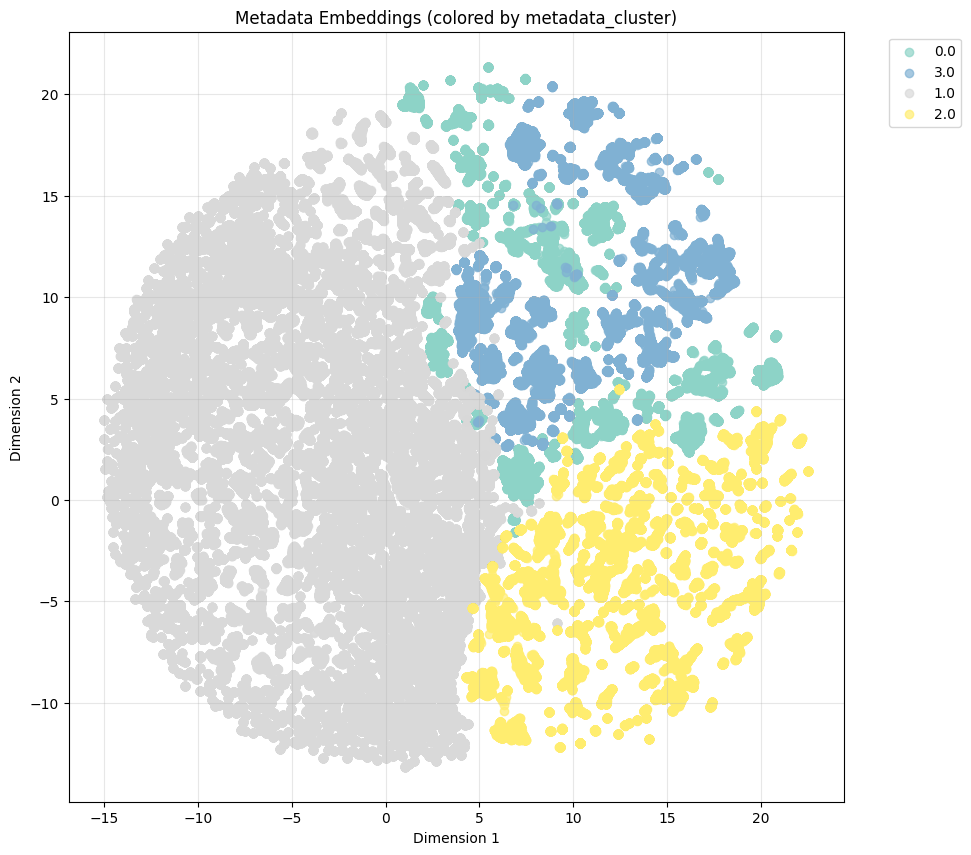

In [ ]:
plot_embeddings(reduced_embeddings, metadata_df, color_by='metadata_cluster', save_path = 'integration_of_remapped_data/plots/metadata_embeddings_metadata_cluster.png')

### Save datasets with metadata cluster column

In [25]:
project = 'gut'
species = 'hs'
name = 'AM'
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
counts = 'raw'

+ E-MTAB-8901

In [27]:
E8901.obs['metadata_cluster'].value_counts()

metadata_cluster
3    77604
0    54019
Name: count, dtype: int64

In [28]:
atribute = 'Elementaite2021_E-MTAB-8901'
current_history = E8901.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Add metadata clusters using sentence-transformers',
})
current_history.append(new_entry)

E8901.uns['processing_history'] = current_history

In [29]:
E8901.uns['processing_history']

['{"step": "added qc metrics (generated with sctk), doublets info, filtered cells with less than 100 genes", "timestamp": "25112024_121501"}',
 '{"timestamp": "02122024_143702", "step": "filtered cells based on consensus qc generated with sctk (default parameters), added sex covariates and cell cycle phase"}',
 '{"timestamp": "17122024_164056", "step": "Metadata harmonized for integration with other datasets"}',
 '{"timestamp": "18122024_124621", "step": "Add metadata clusters using sentence-transformers"}']

In [ ]:
E8901.write_h5ad(f"Elementaite_2021/{project}_{species}_{atribute}_metadata_with_embedding_{name}_{timestamp}_{counts}.h5ad")

+ E-MTAB-9536

In [31]:
E9536.obs['metadata_cluster'].value_counts()

metadata_cluster
2    31494
Name: count, dtype: int64

In [32]:
atribute = 'Elementaite2021_E-MTAB-9536'
current_history = E9536.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Add metadata clusters using sentence-transformers',
})
current_history.append(new_entry)

E9536.uns['processing_history'] = current_history

In [33]:
E9536.uns['processing_history']

['{"step": "create raw anndata after mapping, no filtering", "timestamp": "31102024_105424"}',
 '{"timestamp": "13112024_101436", "step": "added qc metrics (generated with sctk), doublets info, filtered cells with less than 100 genes"}',
 '{"timestamp": "13112024_104420", "step": "filtered cells based on consensus qc generated with sctk (default parameters), added sex covariates and cell cycle phase"}',
 '{"timestamp": "17122024_164056", "step": "Metadata harmonized for integration with other datasets"}',
 '{"timestamp": "18122024_124621", "step": "Add metadata clusters using sentence-transformers"}']

In [ ]:
E9536.write_h5ad(f"Elementaite_2021/{project}_{species}_{atribute}_metadata_with_embedding_{name}_{timestamp}_{counts}.h5ad")

+ E-MTAB-9543

In [36]:
E9543.obs['metadata_cluster'].value_counts()

metadata_cluster
2    62586
Name: count, dtype: int64

In [37]:
atribute = 'Elementaite2021_E-MTAB-9543'
current_history = E9543.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Add metadata clusters using sentence-transformers',
})
current_history.append(new_entry)

E9543.uns['processing_history'] = current_history

In [38]:
E9543.uns['processing_history']

['{"step": "create raw anndata after mapping, no filtering", "timestamp": "05112024_113505"}',
 '{"timestamp": "09122024_154541", "step": "doublets info; filtered cells with less than 100 genes; filtered cells: pct_mito <50, n_genes>50, n_counts>500, percent_hb<2, total_counts<9000, n_genes_by_counts<5000; added sex covariates and cell cycle phase"}',
 '{"timestamp": "17122024_164056", "step": "Metadata harmonized for integration with other datasets"}',
 '{"timestamp": "18122024_124621", "step": "Add metadata clusters using sentence-transformers"}']

In [ ]:
E9543.write_h5ad(f"Elementaite_2021/{project}_{species}_{atribute}_metadata_with_embedding_{name}_{timestamp}_{counts}.h5ad")

+ E-MTAB-9489

In [40]:
E9489.obs['metadata_cluster'].value_counts()

metadata_cluster
1    223842
Name: count, dtype: int64

In [41]:
atribute = 'Holloway2021_E-MTAB-9489'
current_history = E9489.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Add metadata clusters using sentence-transformers',
})
current_history.append(new_entry)

E9489.uns['processing_history'] = current_history

In [42]:
E9489.uns['processing_history']

['{"step": "added qc metrics (generated with sctk), doublets info, filtered cells with less than 100 genes", "timestamp": "27112024_122219"}',
 '{"timestamp": "09122024_100120", "step": "filtered cells based on consensus qc generated with sctk (default parameters), added sex covariates and cell cycle phase"}',
 '{"timestamp": "17122024_164056", "step": "Metadata harmonized for integration with other datasets"}',
 '{"timestamp": "18122024_124621", "step": "Add metadata clusters using sentence-transformers"}']

In [ ]:
E9489.write_h5ad(f"Holloway_2021/{project}_{species}_{atribute}_metadata_with_embedding_{name}_{timestamp}_{counts}.h5ad")

+ E-MTAB-9720

In [44]:
E9720.obs['metadata_cluster'].value_counts()

metadata_cluster
0    10558
Name: count, dtype: int64

In [45]:
atribute = 'Holloway2021_E-MTAB-9720'
current_history = E9720.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Add metadata clusters using sentence-transformers',
})
current_history.append(new_entry)

E9720.uns['processing_history'] = current_history

In [46]:
E9720.uns['processing_history']

['{"step": "create raw anndata after mapping, no filtering", "timestamp": "06112024_121025"}',
 '{"timestamp": "27112024_160858", "step": "added qc metrics (generated with sctk), doublets info, filtered cells with less than 100 genes"}',
 '{"timestamp": "09122024_103213", "step": "filtered cells based on consensus qc generated with sctk (default parameters), added sex covariates and cell cycle phase"}',
 '{"timestamp": "17122024_164056", "step": "Metadata harmonized for integration with other datasets"}',
 '{"timestamp": "18122024_124621", "step": "Add metadata clusters using sentence-transformers"}']

In [ ]:
E9720.write_h5ad(f"Holloway_2021/{project}_{species}_{atribute}_metadata_with_embedding_{name}_{timestamp}_{counts}.h5ad")